# gemma4:e4b — where the pipeline gets it wrong

Two things, in order:

1. **The confusion matrix** — every real item, sorted by what the pipeline actually
   labeled it as. This is the fastest way to tell if the pipeline works: a matrix that's
   almost all diagonal means it's labeling correctly; a matrix with a lot of weight
   elsewhere means it's systematically confusing two particular label types.
2. **Only the items that didn't get labeled correctly**, one row per item, across all 10
   samples — no items that matched are shown.

Both cover **Path B**: the pipeline's final output (after the annotation rules run),
checked against the revised answer key.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import LABELS, extract_gold, _match_structured
from dmpbridge.evaluation.annotation_rules import (
    load_method_new, convert_tag_to_final, resolve_new_gt_path,
)

MODEL, TAG = 'gemma4:e4b', 'gemma4-e4b_pdfplumber_whole_doc'
SAMPLES = range(1, 11)

pd.set_option('display.max_colwidth', None)   # never truncate the text column
INK, SURFACE = '#0b0b0b', '#fcfcfb'

df_b, conf_b, err_b = load_method_new(TAG, exclude=[])
if df_b is None:
    convert_tag_to_final(TAG)
    df_b, conf_b, err_b = load_method_new(TAG, exclude=[])
print(f'{MODEL}: {len(df_b)} documents scored')


gemma4:e4b: 10 documents scored


## 1. Confusion matrix — raw counts

Rows are the true label, columns are what the pipeline actually produced.
**The `(not labeled)` column is items the pipeline never produced anything for at
all** — it isn't a label choice, it's the absence of one. Read across a row to see
everything that happened to one true class; the diagonal cell is how many it got right.


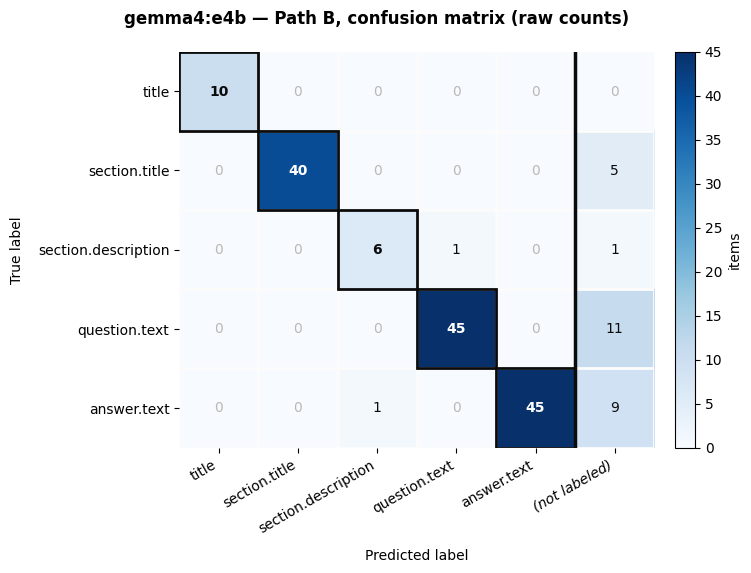

In [2]:
COLS = list(LABELS) + ['(not labeled)']
KEYS = list(LABELS) + ['__missed__']

counts = np.zeros((len(LABELS), len(KEYS)), dtype=int)
for i, t in enumerate(LABELS):
    for j, key in enumerate(KEYS):
        counts[i, j] = conf_b.get(t, {}).get(key, 0)

fig, ax = plt.subplots(figsize=(7.6, 5.8))
im = ax.imshow(counts, cmap='Blues', vmin=0, vmax=counts.max())
for i in range(len(LABELS)):
    for j in range(len(KEYS)):
        v = int(counts[i, j])
        ax.text(j, i, str(v) if v else '0', ha='center', va='center', fontsize=10,
                fontweight='bold' if i == j else 'normal',
                color='#b9b9b4' if v == 0 else ('white' if v / counts.max() > 0.55 else INK))

ax.set_xticks(range(len(COLS)))
ax.set_xticklabels(COLS, rotation=30, ha='right')
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted label', labelpad=10)
ax.set_ylabel('True label', labelpad=10)

ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
ax.grid(which='minor', color=SURFACE, linewidth=2)
ax.tick_params(which='minor', length=0)
for k in range(len(LABELS)):
    ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                               edgecolor=INK, linewidth=2.0, zorder=5))
ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
ax.get_xticklabels()[-1].set_style('italic')
for spine in ax.spines.values():
    spine.set_visible(False)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='items')
fig.suptitle(f'{MODEL} \u2014 Path B, confusion matrix (raw counts)', fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Items not labeled correctly

One row per item, only where the pipeline's answer disagrees with the answer key —
either it labeled the text as the wrong type, produced nothing for a real item, or
produced an item the answer key doesn't have at all.

**Only the first two of those three (`wrong label`, `missing`) are the errors the
matrix above can show.** The matrix has one row per *real* (answer-key) item, so a
wrong label shows up off the diagonal and a missing item shows up in `(not labeled)`.
`extra — not in answer key` items have no real item to be a row of at all — they're
the pipeline producing something nobody asked for — so they exist only in the table
below, never in the matrix. That's the whole reason the two totals don't match.


In [3]:
rows = []
for n in SAMPLES:
    gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
    records, no_gold = _match_structured(P.final_path(TAG, n), gold, dedup_question_title=False)
    for r in records:
        if r['pred_text'] is None:
            rows.append({'sample': n, 'true label': r['gold_label'],
                         'predicted label': '(not produced)', 'issue': 'missing',
                         'text': r['gold_text']})
        elif r['pred_label'] != r['gold_label']:
            rows.append({'sample': n, 'true label': r['gold_label'],
                         'predicted label': r['pred_label'], 'issue': 'wrong label',
                         'text': r['pred_text']})
    for text, label in no_gold:
        rows.append({'sample': n, 'true label': '(none)', 'predicted label': label,
                     'issue': 'extra \u2014 not in answer key', 'text': text})

errors = pd.DataFrame(rows, columns=['sample', 'true label', 'predicted label', 'issue', 'text'])
total_gold = sum(len(extract_gold(resolve_new_gt_path(n), dedup_question_title=False)) for n in SAMPLES)
in_matrix = (errors['issue'] != 'extra \u2014 not in answer key').sum()
not_in_matrix = (errors['issue'] == 'extra \u2014 not in answer key').sum()
correct = total_gold - in_matrix

print(f'{total_gold} real (answer-key) items total \u2014 this is what the matrix rows sum to')
print(f'  {correct} correct (the matrix diagonal)')
print(f'  {in_matrix} wrong or missing (visible in the matrix, off-diagonal / "(not labeled)")')
print(f'  + {not_in_matrix} extra items with no real counterpart (NOT in the matrix at all)')
print(f'  = {len(errors)} rows in the table below')
print()
display(errors.groupby(['sample', 'issue']).size().unstack(fill_value=0))


174 real (answer-key) items total — this is what the matrix rows sum to
  146 correct (the matrix diagonal)
  28 wrong or missing (visible in the matrix, off-diagonal / "(not labeled)")
  + 15 extra items with no real counterpart (NOT in the matrix at all)
  = 43 rows in the table below



issue,extra — not in answer key,missing,wrong label
sample,,,
1,1,1,0
2,5,7,0
3,1,2,1
5,5,1,1
6,3,15,0


In [4]:
display(errors)


,sample,true label,predicted label,issue,text
0,1,answer.text,(not produced),missing,"This secondary data analysis project will analyze deidentified data from 48,218 participants from eight studies and the publicly available NHANES cohorts (wrist NHANES 2011-2014; hip/counts-NHANES 2003-2006). The studies include (i) the RISE Study, (ii) the SOL-VIDA Study, (iii) the iWATCH Study, (iv) the MOCA Study, (v) the PHASE Study, (vi) the AusDiab Study, (vii) the ACT Study, and (viii) the WHISH accelerometer substudy."
1,1,(none),answer.text,extra — not in answer key,"This secondary data analysis project will analyze deidentified data from 48,218 participants from eight studies and the publicly available NHANES cohorts (wrist NHANES 2011-2014; hip/counts-NHANES 2003-2006). The studies include (i) the RISE Study, (ii) the SOL-VIDA Study, (iii) the iWATCH Study, (iv) the MOCA Study, (v) the PHASE Study, (vi) the AusDiab Study, (vii) the ACT Study, and (viii) the WHISH accelerometer sub- study."
2,2,question.text,(not produced),missing,Roles & Responsibilities.
3,2,answer.text,(not produced),missing,"For the proposed research, Director Samuel Stupp with help from the Executive Director of Research will take the lead and responsibility for coordinating and ensuring data storage and access and communicating expectations to all investigators. However, all senior investigators will also be involved in managing, storing, and disseminating the results of the project and will be responsible for checking that the plan is being followed."
4,2,question.text,(not produced),missing,Data Repositories.
5,2,answer.text,(not produced),missing,"Senior investigators typically archive relevant data using their own group servers. Whenever possible, investigators will be encouraged to also copy data to a centralized data server for CBES investigators. Additionally, researchers can archive data on repositories at their home institutions. For example, researchers at Northwestern are encouraged to deposit data into Northwestern Libraries' institutional repository, Arch, upon publication (https://arch.library.northwestern.edu/). Arch assigns DOIs, making it easy to find the data. Necessary metadata and other resources to make the data accessible to future users will be submitted. Arch will preserve the data for future use."
6,2,question.text,(not produced),missing,Data Volume.
7,2,answer.text,(not produced),missing,"Generally, the volume of data generated by CBES researchers should not prohibit their deposition in available repositories. However, in cases where large volumes of data are generated (e.g., temperature/time dependent microscopy or X-ray studies), the data may need to be averaged, condensed, or minimally processed prior to deposition."
8,2,section.description,(not produced),missing,"Data management plans must confidentiality, personal privacy, Personally Identifiable Information and U.S. national, homeland, and economic security; recognize proprietary interests, business confidential information, and intellectual property rights; avoid significant negative impact on innovation and U.S. competitiveness; and otherwise be consistent with all applicable laws, regulations, agreement terms and conditions, and DOE orders and policies. There is no requirement to share proprietary data."
9,2,(none),question.text,extra — not in answer key,1. Data sharing and preservation
